# Exploratory Data Analysis

This notebook analyzes sales, customer, product, branch, inventory, and survey data to identify key business insights and opportunities.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from pathlib import Path

DATA_DIR = Path("../data/cleaned")

sales = pd.read_csv(DATA_DIR / "sales_transaction.csv")
sales_line = pd.read_csv(DATA_DIR / "sales_transactionline.csv")
products = pd.read_csv(DATA_DIR / "product_master.csv")
customers = pd.read_csv(DATA_DIR / "customers.csv")
branches = pd.read_csv(DATA_DIR / "branch_master.csv")
inventory = pd.read_csv(DATA_DIR / "inventory_daily.csv")
survey = pd.read_csv(DATA_DIR / "survey_feedback.csv")

In [3]:
sales["transaction_ts"] = pd.to_datetime(sales["transaction_ts"])
sales["sales_date"] = pd.to_datetime(sales["sales_date"])

customers["join_date"] = pd.to_datetime(customers["join_date"])

inventory["inventory_date"] = pd.to_datetime(inventory["inventory_date"])

survey["feedback_date"] = pd.to_datetime(survey["feedback_date"])

## 2. Analysis Dataset

In [4]:
sales_analysis = sales.merge(
    branches[["branch_id", "branch_name", "zone", "store_size"]],
    on="branch_id",
    how="left"
)

sales_analysis = sales_analysis.merge(
    customers[["customer_id", "seed_segment", "gender", "age", "loyalty_channel"]],
    on="customer_id",
    how="left"
)

In [5]:
sales_product = sales_line.merge(
    products,
    on="product_code",
    how="left"
)

## 3. Sales Performance

In [6]:
total_revenue = sales["basket_amount"].sum()
total_transactions = sales["transaction_id"].nunique()
average_basket = sales["basket_amount"].mean()

print(f"Revenue: {total_revenue:,.0f}")
print(f"Transactions: {total_transactions:,}")
print(f"Average Basket: {average_basket:,.0f}")

Revenue: 69,193,900
Transactions: 5,129
Average Basket: 13,491


In [7]:
daily_sales = (
    sales.groupby("sales_date")
    .agg(
        revenue=("basket_amount", "sum"),
        transactions=("transaction_id", "nunique")
    )
    .reset_index()
)

daily_sales["average_basket"] = (
    daily_sales["revenue"] / daily_sales["transactions"]
)

daily_sales.head()

,sales_date,revenue,transactions,average_basket
0,2025-01-01,730800,51,14329.411765
1,2025-01-02,577600,53,10898.113208
2,2025-01-03,842900,64,13170.312500
3,2025-01-04,818500,64,12789.062500
4,2025-01-05,880000,62,14193.548387


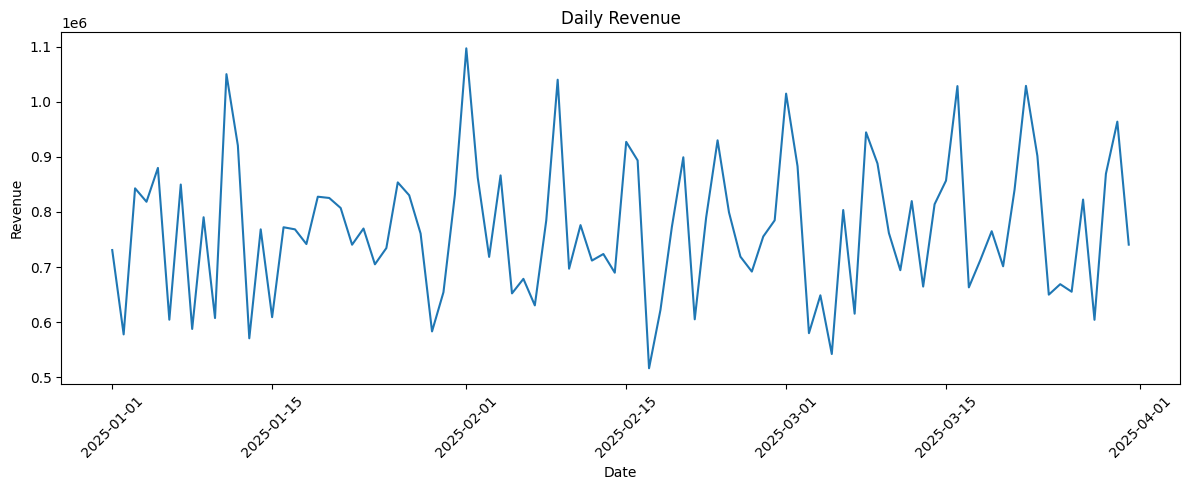

In [8]:
plt.figure(figsize=(12, 5))

plt.plot(
    daily_sales["sales_date"],
    daily_sales["revenue"]
)

plt.title("Daily Revenue")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [9]:
monthly_sales = (
    sales.assign(month=sales["sales_date"].dt.to_period("M"))
    .groupby("month")
    .agg(
        revenue=("basket_amount", "sum"),
        transactions=("transaction_id", "nunique")
    )
    .reset_index()
)

monthly_sales["average_basket"] = (
    monthly_sales["revenue"] / monthly_sales["transactions"]
)

monthly_sales

,month,revenue,transactions,average_basket
0,2025-01,23413000,1755,13340.740741
1,2025-02,21634900,1573,13753.909727
2,2025-03,24146000,1801,13406.996113


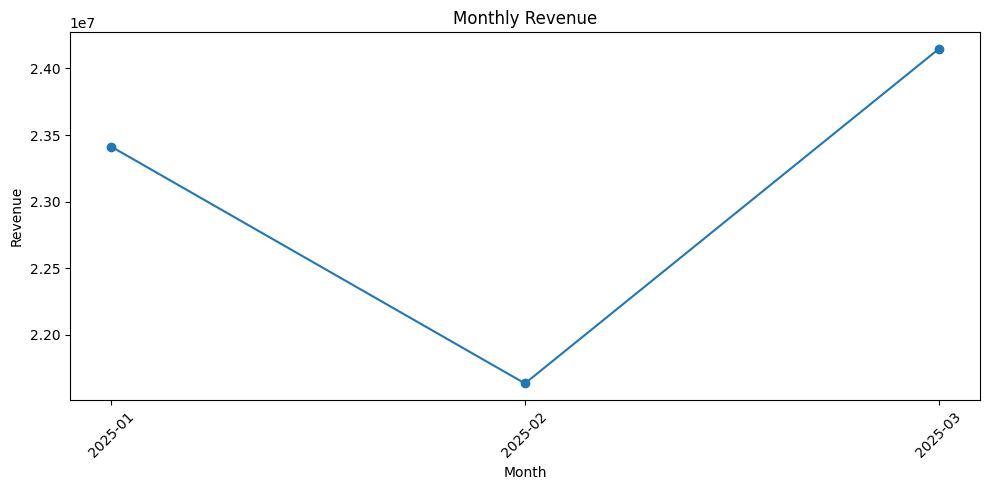

In [10]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales["month"].astype(str),
    monthly_sales["revenue"],
    marker="o"
)

plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
monthly_sales["revenue_change_pct"] = (
    monthly_sales["revenue"].pct_change() * 100
).round(1)

monthly_sales["transaction_change_pct"] = (
    monthly_sales["transactions"].pct_change() * 100
).round(1)

monthly_sales["basket_change_pct"] = (
    monthly_sales["average_basket"].pct_change() * 100
).round(1)

print(
    monthly_sales[
        [
            "month",
            "revenue",
            "transactions",
            "average_basket",
            "revenue_change_pct",
            "transaction_change_pct",
            "basket_change_pct"
        ]
    ].to_string(index=False)
)

  month  revenue  transactions  average_basket  revenue_change_pct  transaction_change_pct  basket_change_pct
2025-01 23413000          1755    13340.740741                 NaN                     NaN                NaN
2025-02 21634900          1573    13753.909727                -7.6                   -10.4                3.1
2025-03 24146000          1801    13406.996113                11.6                    14.5               -2.5


In [12]:
branch_sales = (
    sales_analysis
    .groupby(["branch_id", "branch_name", "zone"])
    .agg(
        revenue=("basket_amount", "sum"),
        transactions=("transaction_id", "nunique")
    )
    .reset_index()
)

branch_sales["average_basket"] = (
    branch_sales["revenue"] /
    branch_sales["transactions"]
)

branch_sales["revenue_share"] = (
    branch_sales["revenue"] /
    branch_sales["revenue"].sum() * 100
).round(1)

print(
    branch_sales
    .sort_values("revenue", ascending=False)
    .to_string(index=False)
)

branch_id branch_name             zone  revenue  transactions  average_basket  revenue_share
      B03    Branch 3 Residential east 12100700           904    13385.730088           17.5
      B05    Branch 5       University 11770200           887    13269.673055           17.0
      B04    Branch 4 Residential west 11643900           882    13201.700680           16.8
      B01    Branch 1         Downtown 11543700           863    13376.245655           16.7
      B02    Branch 2  Office district 11329500           820    13816.463415           16.4
      B06    Branch 6          Transit 10805900           773    13979.172057           15.6


In [13]:
customer_segment = (
    sales_analysis
    .dropna(subset=["customer_id"])
    .groupby("seed_segment")
    .agg(
        revenue=("basket_amount", "sum"),
        transactions=("transaction_id", "nunique"),
        customers=("customer_id", "nunique")
    )
    .reset_index()
)

customer_segment["average_basket"] = (
    customer_segment["revenue"] /
    customer_segment["transactions"]
)

customer_segment["revenue_share"] = (
    customer_segment["revenue"] /
    customer_segment["revenue"].sum() * 100
).round(1)

print(customer_segment.to_string(index=False))

        seed_segment  revenue  transactions  customers  average_basket  revenue_share
     Family stock-up  6666700           505         15    13201.386139           11.5
     Healthy routine  9088300           677         18    13424.372230           15.7
        Lunch office 12125800           902         26    13443.237251           21.0
    Morning commuter 13865100          1016         27    13646.751969           24.0
Student value seeker 16054200          1173         34    13686.445013           27.8


In [15]:
customer_segment["transactions_per_customer"] = (
    customer_segment["transactions"] /
    customer_segment["customers"]
).round(1)

customer_segment["revenue_per_customer"] = (
    customer_segment["revenue"] /
    customer_segment["customers"]
).round(0)

print(
    customer_segment[
        [
            "seed_segment",
            "customers",
            "transactions_per_customer",
            "revenue_per_customer",
            "average_basket"
        ]
    ]
    .sort_values("revenue_per_customer", ascending=False)
    .to_string(index=False)
)

        seed_segment  customers  transactions_per_customer  revenue_per_customer  average_basket
    Morning commuter         27                       37.6              513522.0    13646.751969
     Healthy routine         18                       37.6              504906.0    13424.372230
Student value seeker         34                       34.5              472182.0    13686.445013
        Lunch office         26                       34.7              466377.0    13443.237251
     Family stock-up         15                       33.7              444447.0    13201.386139


In [16]:
customer_activity = (
    sales_analysis
    .dropna(subset=["customer_id"])
    .groupby("customer_id")
    .agg(
        transactions=("transaction_id", "nunique"),
        revenue=("basket_amount", "sum")
    )
    .reset_index()
)

customer_activity["customer_type"] = np.where(
    customer_activity["transactions"] == 1,
    "One-time",
    "Repeat"
)

print(
    customer_activity["customer_type"]
    .value_counts()
    .to_string()
)

customer_type
Repeat    120


In [17]:
repeat_summary = (
    customer_activity
    .groupby("customer_type")
    .agg(
        customers=("customer_id", "count"),
        transactions=("transactions", "sum"),
        revenue=("revenue", "sum")
    )
    .reset_index()
)

repeat_summary["revenue_share"] = (
    repeat_summary["revenue"] /
    repeat_summary["revenue"].sum() * 100
).round(1)

print(repeat_summary.to_string(index=False))

customer_type  customers  transactions  revenue  revenue_share
       Repeat        120          4273 57800100          100.0


In [18]:
print(
    customer_activity["transactions"]
    .describe()
    .round(1)
    .to_string()
)

count    120.0
mean      35.6
std        6.2
min       18.0
25%       32.0
50%       35.0
75%       39.2
max       50.0


In [19]:
print(
    customer_activity["transactions"]
    .value_counts()
    .sort_index()
    .to_string()
)

transactions
18     1
19     1
22     1
24     1
26     4
27     1
28     2
29     5
30     6
31     7
32    13
33     2
34    11
35    10
36     5
37     6
38     6
39     8
40     6
41     4
42     2
43     3
44     1
45     4
46     3
47     4
48     2
50     1


In [20]:
product_performance = (
    sales_product
    .groupby(["product_code", "product_name", "category_name"])
    .agg(
        units_sold=("qty", "sum"),
        revenue=("line_amount", "sum"),
        transactions=("transaction_id", "nunique")
    )
    .reset_index()
)

product_performance["revenue_share"] = (
    product_performance["revenue"] /
    product_performance["revenue"].sum() * 100
).round(1)

print(
    product_performance
    .sort_values("revenue", ascending=False)
    .to_string(index=False)
)

product_code          product_name category_name  units_sold  revenue  transactions  revenue_share
      RTE004             Pasta Box    ReadyToEat         941  7988500           721           11.5
      HOU003          Batteries AA     Household         923  6258800           698            9.0
      RTE002           Tuna Kimbap    ReadyToEat         877  6199000           659            9.0
      RTE001      Chicken Sandwich    ReadyToEat         891  5684000           682            8.2
      DES002      Cheesecake Slice       Dessert         895  5176800           680            7.5
      SNK003           Protein Bar        Snacks         902  4590300           672            6.6
      RTE003          Beef Onigiri    ReadyToEat         869  4069400           648            5.9
      BEV003           Iced Coffee      Beverage         935  3820600           698            5.5
      SNK002      Corn Chips Spicy        Snacks         863  3527400           650            5.1
      SNK0

In [21]:
category_performance = (
    sales_product
    .groupby("category_name")
    .agg(
        units_sold=("qty", "sum"),
        revenue=("line_amount", "sum"),
        transactions=("transaction_id", "nunique")
    )
    .reset_index()
)

category_performance["revenue_share"] = (
    category_performance["revenue"] /
    category_performance["revenue"].sum() * 100
).round(1)

category_performance["average_revenue_per_transaction"] = (
    category_performance["revenue"] /
    category_performance["transactions"]
).round(0)

print(
    category_performance
    .sort_values("revenue", ascending=False)
    .to_string(index=False)
)

category_name  units_sold  revenue  transactions  revenue_share  average_revenue_per_transaction
   ReadyToEat        3578 23940900          2278           34.6                          10510.0
       Snacks        3552 13864400          2244           20.0                           6178.0
      Dessert        2719 11005600          1802           15.9                           6107.0
    Household        2656 10540200          1815           15.2                           5807.0
     Beverage        3679  9842800          2294           14.2                           4291.0


In [22]:
product_performance["revenue_per_unit"] = (
    product_performance["revenue"] /
    product_performance["units_sold"]
).round(0)

print(
    product_performance[
        [
            "product_name",
            "units_sold",
            "revenue",
            "revenue_per_unit"
        ]
    ]
    .sort_values("revenue_per_unit", ascending=False)
    .to_string(index=False)
)

         product_name  units_sold  revenue  revenue_per_unit
            Pasta Box         941  7988500            8489.0
          Tuna Kimbap         877  6199000            7068.0
         Batteries AA         923  6258800            6781.0
     Chicken Sandwich         891  5684000            6379.0
     Cheesecake Slice         895  5176800            5784.0
          Protein Bar         902  4590300            5089.0
         Beef Onigiri         869  4069400            4683.0
     Corn Chips Spicy         863  3527400            4087.0
          Iced Coffee         935  3820600            4086.0
Potato Chips Sea Salt         940  3465700            3687.0
        Ice Cream Bar         931  3151500            3385.0
           Yogurt Cup         893  2677300            2998.0
            Wet Wipes         847  2346600            2770.0
      Chocolate Wafer         847  2281000            2693.0
     Green Tea Bottle         912  2265700            2484.0
           Cola 500ml   

In [23]:
inventory_status = (
    inventory
    .groupby(["product_code", "stock_flag"])
    .size()
    .unstack(fill_value=0)
    .reset_index()
)

for col in ["OK", "LOW", "OOS"]:
    if col not in inventory_status.columns:
        inventory_status[col] = 0

inventory_status["total_days"] = (
    inventory_status["OK"] +
    inventory_status["LOW"] +
    inventory_status["OOS"]
)

inventory_status["low_rate"] = (
    inventory_status["LOW"] /
    inventory_status["total_days"] * 100
).round(1)

inventory_status["oos_rate"] = (
    inventory_status["OOS"] /
    inventory_status["total_days"] * 100
).round(1)

print(
    inventory_status
    .sort_values("oos_rate", ascending=False)
    .to_string(index=False)
)

product_code  LOW  OK  OOS  total_days  low_rate  oos_rate
      RTE003   94 141    5         240      39.2       2.1
      DES002   74 161    5         240      30.8       2.1
      BEV004   94 165    5         264      35.6       1.9
      RTE004   63 155    4         222      28.4       1.8
      SNK004   76 166    4         246      30.9       1.6
      BEV001   84 159    3         246      34.1       1.2
      BEV003   91 164    3         258      35.3       1.2
      SNK003   77 149    2         228      33.8       0.9
      HOU001   87 145    2         234      37.2       0.9
      BEV002   80 176    2         258      31.0       0.8
      SNK002   81 175    2         258      31.4       0.8
      HOU002  107 197    2         306      35.0       0.7
      RTE002   49 124    1         174      28.2       0.6
      DES001   77 138    1         216      35.6       0.5
      SNK001   77 132    1         210      36.7       0.5
      HOU003   86 159    1         246      35.0       0

In [24]:
inventory_risk = inventory_status.merge(
    product_performance[
        ["product_code", "product_name", "category_name", "revenue", "units_sold"]
    ],
    on="product_code",
    how="left"
)

print(
    inventory_risk[
        [
            "product_code",
            "product_name",
            "category_name",
            "revenue",
            "units_sold",
            "low_rate",
            "oos_rate"
        ]
    ]
    .sort_values("revenue", ascending=False)
    .to_string(index=False)
)

product_code          product_name category_name  revenue  units_sold  low_rate  oos_rate
      RTE004             Pasta Box    ReadyToEat  7988500         941      28.4       1.8
      HOU003          Batteries AA     Household  6258800         923      35.0       0.4
      RTE002           Tuna Kimbap    ReadyToEat  6199000         877      28.2       0.6
      RTE001      Chicken Sandwich    ReadyToEat  5684000         891      29.5       0.0
      DES002      Cheesecake Slice       Dessert  5176800         895      30.8       2.1
      SNK003           Protein Bar        Snacks  4590300         902      33.8       0.9
      RTE003          Beef Onigiri    ReadyToEat  4069400         869      39.2       2.1
      BEV003           Iced Coffee      Beverage  3820600         935      35.3       1.2
      SNK002      Corn Chips Spicy        Snacks  3527400         863      31.4       0.8
      SNK001 Potato Chips Sea Salt        Snacks  3465700         940      36.7       0.5
      DES0

In [25]:
survey_summary = {
    "average_quality_score": survey["quality_score"].mean(),
    "average_visual_score": survey["visual_score"].mean(),
    "would_buy_again_yes_pct": (
        (survey["would_buy_again"] == "yes").mean() * 100
    ),
    "would_buy_again_maybe_pct": (
        (survey["would_buy_again"] == "maybe").mean() * 100
    ),
    "would_buy_again_no_pct": (
        (survey["would_buy_again"] == "no").mean() * 100
    )
}

for metric, value in survey_summary.items():
    print(f"{metric}: {value:.1f}")

average_quality_score: 6.7
average_visual_score: 6.5
would_buy_again_yes_pct: 43.8
would_buy_again_maybe_pct: 25.8
would_buy_again_no_pct: 30.4


In [26]:
repurchase_analysis = (
    survey
    .groupby("would_buy_again")
    .agg(
        feedback_count=("feedback_id", "count"),
        avg_quality=("quality_score", "mean"),
        avg_visual=("visual_score", "mean")
    )
    .reset_index()
)

print(repurchase_analysis.to_string(index=False))

would_buy_again  feedback_count  avg_quality  avg_visual
          maybe             232     6.857759    6.435345
             no             274     5.989051    6.310219
            yes             394     7.172589    6.601523


In [28]:
product_feedback = (
    survey
    .groupby("product_code")
    .agg(
        feedback_count=("feedback_id", "count"),
        avg_quality=("quality_score", "mean"),
        avg_visual=("visual_score", "mean")
    )
    .reset_index()
)

product_feedback = product_feedback.merge(
    products[["product_code", "product_name", "category_name"]],
    on="product_code",
    how="left"
)

print(
    product_feedback
    .sort_values("avg_quality")
    .to_string(index=False)
)

product_code  feedback_count  avg_quality  avg_visual          product_name category_name
      BEV003              53     6.283019    6.792453           Iced Coffee      Beverage
      SNK003              38     6.394737    6.157895           Protein Bar        Snacks
      RTE001              51     6.470588    6.058824      Chicken Sandwich    ReadyToEat
      BEV004              45     6.488889    6.266667      Green Tea Bottle      Beverage
      BEV001              56     6.500000    6.214286            Cola 500ml      Beverage
      HOU002              51     6.549020    6.784314           Tissue Pack     Household
      HOU001              55     6.600000    6.418182             Wet Wipes     Household
      HOU003              46     6.652174    6.630435          Batteries AA     Household
      RTE004              51     6.745098    6.333333             Pasta Box    ReadyToEat
      DES003              42     6.785714    6.404762         Ice Cream Bar       Dessert
      BEV0

In [29]:
product_matrix = (
    product_performance[
        [
            "product_code",
            "product_name",
            "category_name",
            "revenue",
            "units_sold"
        ]
    ]
    .merge(
        product_feedback[
            [
                "product_code",
                "feedback_count",
                "avg_quality",
                "avg_visual"
            ]
        ],
        on="product_code",
        how="left"
    )
    .merge(
        inventory_status[
            [
                "product_code",
                "low_rate",
                "oos_rate"
            ]
        ],
        on="product_code",
        how="left"
    )
)

print(
    product_matrix
    .sort_values("revenue", ascending=False)
    .to_string(index=False)
)

product_code          product_name category_name  revenue  units_sold  feedback_count  avg_quality  avg_visual  low_rate  oos_rate
      RTE004             Pasta Box    ReadyToEat  7988500         941              51     6.745098    6.333333      28.4       1.8
      HOU003          Batteries AA     Household  6258800         923              46     6.652174    6.630435      35.0       0.4
      RTE002           Tuna Kimbap    ReadyToEat  6199000         877              46     6.847826    6.608696      28.2       0.6
      RTE001      Chicken Sandwich    ReadyToEat  5684000         891              51     6.470588    6.058824      29.5       0.0
      DES002      Cheesecake Slice       Dessert  5176800         895              49     7.224490    6.653061      30.8       2.1
      SNK003           Protein Bar        Snacks  4590300         902              38     6.394737    6.157895      33.8       0.9
      RTE003          Beef Onigiri    ReadyToEat  4069400         869              

## EDA Summary

### Sales
- Total revenue: 69.19M
- Total transactions: 5,129
- Average basket: 13,491
- Monthly revenue changes were primarily driven by transaction volume.

### Customers
- 120 identified customers were repeat customers.
- Average purchase frequency was 35.6 transactions per customer.
- Student value seekers contributed the largest identified-customer revenue share.

### Products
- ReadyToEat generated the highest category revenue share at 34.6%.
- Pasta Box was the top product by revenue at 8.0M.
- High unit volume did not always translate into high revenue.

### Inventory
- Pasta Box, Cheesecake Slice, and Beef Onigiri showed notable inventory pressure.
- Inventory flags were retained as provided because no deterministic rule was identified.

### Survey
- Average quality score: 6.7/10.
- Average visual score: 6.5/10.
- 43.8% of respondents said they would buy again.
- Quality scores were higher among respondents who would buy again.